In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv(r"C:\Users\erik_\OneDrive\Desktop\amazon_sales_dataset.csv")
print(df.columns)

Index(['order_id', 'order_date', 'product_id', 'product_category', 'price',
       'discount_percent', 'quantity_sold', 'customer_region',
       'payment_method', 'rating', 'review_count', 'discounted_price',
       'total_revenue'],
      dtype='object')


In [103]:
df = pd.read_csv(r"C:\Users\erik_\OneDrive\Desktop\amazon_sales_dataset.csv")
print("--- 2. Unique products ID ---")
#
unique_products = df['product_id'].nunique()
print(f"Unique: {unique_products}\n")

--- 2. Unique products ID ---
Unique: 4000



In [60]:
df = pd.read_csv(r"C:\Users\erik_\OneDrive\Desktop\amazon_sales_dataset.csv")
print("--- 3.Unique product---")
unique_categories = df['product_category'].nunique()
print(f"Unique product: {unique_categories}\n")


--- 3. Unique product---
Unique product: 6



In [104]:
df = pd.read_csv(r"C:\Users\erik_\OneDrive\Desktop\amazon_sales_dataset.csv")
print("--- 4. Columns types ---")
print(df.dtypes)

--- 4. Columns types ---
order_id              int64
order_date           object
product_id            int64
product_category     object
price               float64
discount_percent      int64
quantity_sold         int64
customer_region      object
payment_method       object
rating              float64
review_count          int64
discounted_price    float64
total_revenue       float64
dtype: object


In [68]:
df = pd.read_csv(r"C:\Users\erik_\OneDrive\Desktop\amazon_sales_dataset.csv")
print("--- 5.Missing columns values ---")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

--- 5.Missing columns values ---
Series([], dtype: int64)


In [83]:
df = pd.read_csv(r"C:\Users\erik_\OneDrive\Desktop\amazon_sales_dataset.csv")
print("--- 6.total revenue ---")
total_revenue = df['price'].sum()
print(f"Total revenue: {total_revenue}")

--- 6.total revenue ---
Total revenue: 12625363.0


In [76]:
df = pd.read_csv(r"C:\Users\erik_\OneDrive\Desktop\amazon_sales_dataset.csv")
print("--- 7.Average Order Value ---")
average_order_value = df['price'].mean()
print(f"Average order value: {average_order_value}\n")

--- 7.Average Order Value ---
Average order value: 252.50726



In [80]:
df = pd.read_csv(r"C:\Users\erik_\OneDrive\Desktop\amazon_sales_dataset.csv")
print("--- 8.Frequently Product category---")
most_frequent_category = df['product_category'].mode()[0]
print(f"Frequently product category: {most_frequent_category}")

--- 8.Frequently Product category---
Frequently product category: Beauty


In [95]:
df = pd.read_csv(r"C:\Users\erik_\OneDrive\Desktop\amazon_sales_dataset.csv")
print("--- 9.Famouse payment_method ---")
most_common_payment = df['payment_method'].mode()[0]
print(f"Famouse paymant metod : {most_common_payment}")

--- 9.Famouse payment_method ---
Famouse paymant metod : Wallet


In [101]:
print("--- 10. Highest selling product---")
best_selling_product = df.groupby('product_id')['quantity_sold'].sum().idxmax()
print(f"Highest selling product ID/Name: {best_selling_product}")

--- 10. Highest selling product---
Highest selling product ID/Name: 1087


In [39]:
print("--- 11. Total Revenue by product category ---")
total_revenue_by_cat = df.groupby('product_category')['total_revenue'].sum()
print(total_revenue_by_cat)

--- 11. Total Revenue by product category ---
product_category
Beauty            5550624.97
Books             5484863.03
Electronics       5470594.03
Fashion           5480123.34
Home & Kitchen    5473132.55
Sports            5407235.82
Name: total_revenue, dtype: float64


In [7]:
#12 Գտնել այն կատեգորիան, որն ապահովում է պատվերի ամենաբարձր միջին արժեքը
highest_avg_order_cat = df.groupby('product_category')['total_revenue'].mean().idxmax()
print(highest_avg_order_cat)

Home & Kitchen


In [8]:
#13. Գտնել ըստ եկամտի լավագույն 10 ապրանքները
top_10_products = df.groupby('product_id')['total_revenue'].sum().nlargest(10)
print(top_10_products)

product_id
1931    18885.83
1087    18531.52
1328    18306.73
3537    18071.02
2837    17855.07
1266    17819.13
4386    17806.08
4264    17803.51
3700    17619.14
3377    17201.38
Name: total_revenue, dtype: float64


In [9]:
#14. Հաշվել հաճախորդների միջին գնահատականը ըստ կատեգորիաների
avg_rating_by_cat = df.groupby('product_category')['rating'].mean()
print(avg_rating_by_cat)

product_category
Beauty            2.985186
Books             3.020259
Electronics       2.991298
Fashion           2.987782
Home & Kitchen    2.996706
Sports            2.996891
Name: rating, dtype: float64


In [10]:
#15. Վերլուծել վաճառքների բաշխումը ըստ տարածաշրջանների
sales_by_region = df.groupby('customer_region')['total_revenue'].sum()
print(sales_by_region)

customer_region
Asia             8175199.83
Europe           8112311.57
Middle East      8301844.50
North America    8277217.84
Name: total_revenue, dtype: float64


In [11]:
#16. Գտնել ամենաշատ վաճառք ունեցող ամիսը
df['order_date'] = pd.to_datetime(df['order_date'])
best_month = df.groupby(df['order_date'].dt.to_period('M'))['total_revenue'].sum().idxmax()
print(best_month)

2023-01


In [12]:
#17. Համեմատել եկամուտները ըստ վճարման եղանակների
revenue_by_payment = df.groupby('payment_method')['total_revenue'].sum()
print(revenue_by_payment)

payment_method
Cash on Delivery    6546386.94
Credit Card         6540087.16
Debit Card          6522019.73
UPI                 6579441.44
Wallet              6678638.47
Name: total_revenue, dtype: float64


In [15]:
#18. Առանձնացնել ամենաշատ կարծիքներ (reviews) ունեցող ապրանքները(TOP 5)
top_reviewed_products = df.groupby('product_id')['review_count'].sum().nlargest(5)
print(top_reviewed_products)

product_id
1848    8653
4002    7105
3305    6829
2778    6720
2923    6708
Name: review_count, dtype: int64


In [19]:
#19. Հաշվել յուրաքանչյուր կատեգորիայի վաճառված ապրանքների միջին քանակը
avg_qty_by_cat = df.groupby('product_category')['quantity_sold'].mean()
print(avg_qty_by_cat)

product_category
Beauty            3.003190
Books             3.010088
Electronics       2.992548
Fashion           2.999283
Home & Kitchen    2.996246
Sports            2.994918
Name: quantity_sold, dtype: float64


In [22]:
#20. Գտնել ըստ ընդհանուր ծախսերի լավագույն տարածաշրջանները/հաճախորդներին
top_10_customers = df.groupby('customer_region')['total_revenue'].sum().nlargest(10)
print(top_10_customers)

customer_region
Middle East      8301844.50
North America    8277217.84
Asia             8175199.83
Europe           8112311.57
Name: total_revenue, dtype: float64


In [24]:
#21. Ստեղծել եկամտի (revenue) նոր սյունակ, եթե այն գոյություն չունի
if 'total_revenue' not in df.columns:
    df['total_revenue'] = df['price'] * df['quantity_sold']
print(df[['price', 'quantity_sold', 'total_revenue']].head())

    price  quantity_sold  total_revenue
0  128.75              4         463.52
1  302.60              5        1210.40
2  495.80              2         793.28
3  371.95              4        1264.64
4  201.68              4         806.72


In [27]:
#22. Վերլուծել զեղչի տոկոսի և եկամտի միջև կապը (կորելյացիա)
correlation = df['discount_percent'].corr(df['total_revenue'])
print(f"Correlation(percent--total): {correlation}")

Correlation(percent--total): -0.1443919115441874


In [28]:
#23. Գտնել բարձր վաճառքի ծավալ, բայց ցածր գնահատական ունեցող ապրանքները
high_sales = df['quantity_sold'].quantile(0.75)
low_rating = df['rating'].quantile(0.25)
problematic_products = df[(df['quantity_sold'] >= high_sales) & (df['rating'] <= low_rating)]
print(problematic_products[['product_id', 'quantity_sold', 'rating']])

       product_id  quantity_sold  rating
6            4068              5     1.6
55           2783              4     1.2
59           4611              5     1.3
69           2148              5     1.1
91           1903              5     2.0
...           ...            ...     ...
49947        2327              5     1.7
49950        1293              4     1.3
49962        2811              5     2.0
49977        4991              5     1.3
49988        1173              5     1.1

[5316 rows x 3 columns]


In [29]:
#24. Գտնել ամենաշահութաբեր ապրանքների կատեգորիաները ըստ ընդհանուր եկամտի
profitable_categories = df.groupby('product_category')['total_revenue'].sum().sort_values(ascending=False)
print(profitable_categories)



product_category
Beauty            5550624.97
Books             5484863.03
Fashion           5480123.34
Home & Kitchen    5473132.55
Electronics       5470594.03
Sports            5407235.82
Name: total_revenue, dtype: float64


In [30]:
#25. Հաշվել ամսական եկամտի աճի տեմպը (growth rate)
df['order_date'] = pd.to_datetime(df['order_date'])
monthly_revenue = df.groupby(df['order_date'].dt.to_period('M'))['total_revenue'].sum()
revenue_growth_rate = monthly_revenue.pct_change() * 100
print(revenue_growth_rate)



order_date
2022-01          NaN
2022-02   -10.779179
2022-03     9.936821
2022-04    -1.481388
2022-05     0.205819
2022-06    -1.647834
2022-07    -0.446431
2022-08     7.668057
2022-09    -3.128458
2022-10    -4.925254
2022-11    -3.275207
2022-12     7.366552
2023-01     5.624357
2023-02   -15.421277
2023-03    10.339140
2023-04    -4.347166
2023-05     9.516383
2023-06    -2.555307
2023-07     3.395023
2023-08    -3.179554
2023-09    -3.961409
2023-10     6.333175
2023-11    -6.424394
2023-12     0.064217
Freq: M, Name: total_revenue, dtype: float64


In [31]:
#26. Վերլուծել հաճախորդների գնումների վարքագիծը ըստ տարածաշրջանների
region_behavior = df.groupby('customer_region').agg({
    'total_revenue': ['sum', 'mean'],
    'quantity_sold': 'sum',
    'order_id': 'count'
})
print(region_behavior)

                total_revenue             quantity_sold order_id
                          sum        mean           sum    count
customer_region                                                 
Asia               8175199.83  652.658457         37440    12526
Europe             8112311.57  651.486634         37302    12452
Middle East        8301844.50  663.882007         37694    12505
North America      8277217.84  661.278089         37534    12517


In [42]:
# Ստեղծել հաճախորդների սեգմենտներ ըստ ծախսման մակարդակի (օրինակ՝ Low, Medium, High)
customer_spending = df.groupby('customer_region')['total_revenue'].sum().reset_index()
customer_spending['spending_segment'] = pd.qcut(
    customer_spending['total_revenue'], 
    q=3, 
    labels=['Low', 'Medium', 'High']
)
print(customer_spending)

  customer_region  total_revenue spending_segment
0            Asia     8175199.83              Low
1          Europe     8112311.57              Low
2     Middle East     8301844.50             High
3   North America     8277217.84           Medium


In [33]:
#28. Դասակարգել ապրանքները ըստ եկամտում ունեցած մասնակցության տոկոսի
product_revenue = df.groupby('product_id')['total_revenue'].sum().reset_index()
total_sum = product_revenue['total_revenue'].sum()
product_revenue['revenue_percentage'] = (product_revenue['total_revenue'] / total_sum) * 100
ranked_products = product_revenue.sort_values(by='revenue_percentage', ascending=False)
print(ranked_products)

      product_id  total_revenue  revenue_percentage
931         1931       18885.83            0.057462
87          1087       18531.52            0.056384
328         1328       18306.73            0.055700
2537        3537       18071.02            0.054983
1837        2837       17855.07            0.054326
...          ...            ...                 ...
2715        3715        1162.27            0.003536
3028        4028        1088.07            0.003311
3514        4514        1063.20            0.003235
2054        3054        1050.78            0.003197
2694        3694         558.54            0.001699

[4000 rows x 3 columns]


In [34]:
#29. Գտնել այն ապրանքները, որոնք ունեն ցածր վաճառք կամ ցածր կարծիքների քանակ և կարիք ունեն մարքեթինգային բարելավման
marketing_needed = df.groupby('product_id').agg({
    'quantity_sold': 'sum',
    'review_count': 'sum',
    'total_revenue': 'sum'
}).sort_values(by='total_revenue', ascending=True).head(10)
print(marketing_needed)

            quantity_sold  review_count  total_revenue
product_id                                            
3694                    3           625         558.54
3054                   12           473        1050.78
4514                   10           603        1063.20
4028                    9          1587        1088.07
3715                   11           569        1162.27
1425                   20          2687        1297.63
2297                   14           964        1314.51
4893                   13          1418        1379.32
4702                   18          2288        1425.52
3826                   11          1493        1621.38


In [38]:
#30.5 կարևոր բիզնես պատկերացում  վաճառքի տվյալներից
print("1. Most profitable category:", df.groupby('product_category')['total_revenue'].sum().idxmax())
print("2. Most popular payment method:", df['payment_method'].mode()[0])
print("3. Region with the highest revenue:", df.groupby('customer_region')['total_revenue'].sum().idxmax())
print("4. Average discount percentage:", df['discount_percent'].mean())
print("5. Total revenue:", df['total_revenue'].sum())

1. Most profitable category: Beauty
2. Most popular payment method: Wallet
3. Region with the highest revenue: Middle East
4. Average discount percentage: 13.3407
5. Total revenue: 32866573.740000002


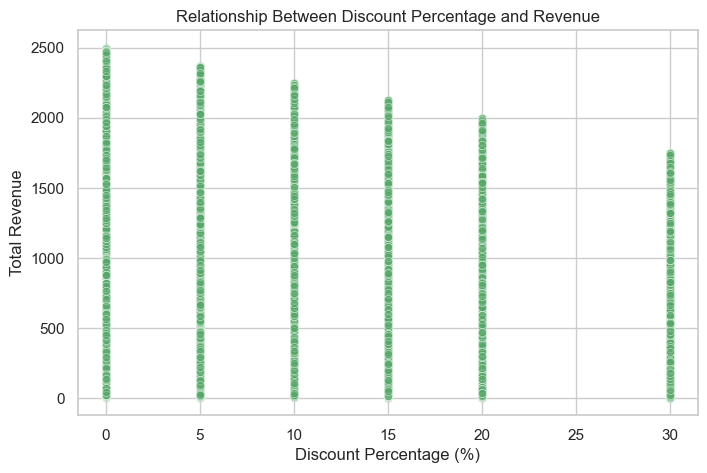

C:\Users\erik_\AppData\Local\Temp\ipykernel_13444\1789058559.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_revenue.index, y=category_revenue.values, palette='viridis')


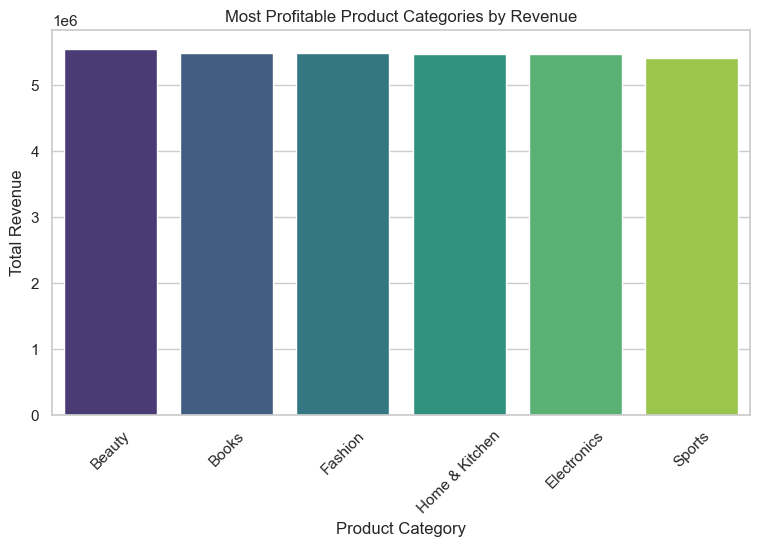

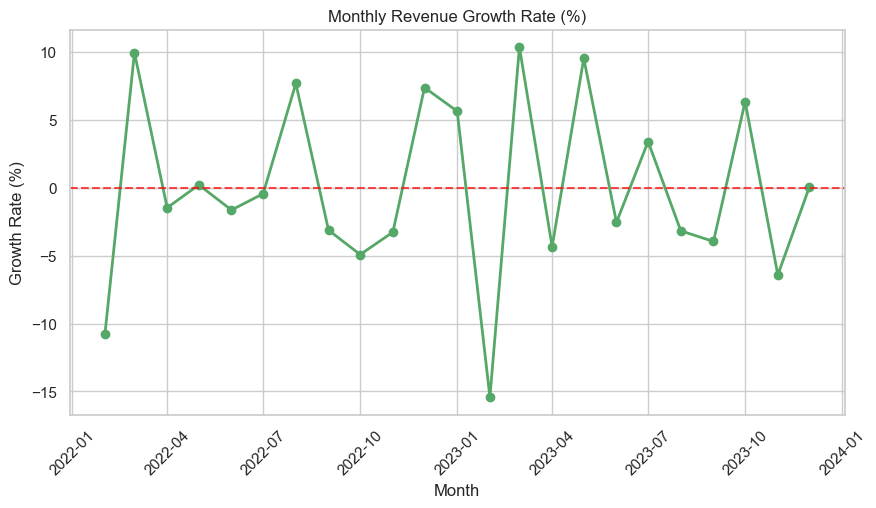

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# --- 22. Analyze the relationship between discount percentage and revenue ---
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='discount_percent', y='total_revenue', alpha=0.6, color='g')
plt.title('Relationship Between Discount Percentage and Revenue')
plt.xlabel('Discount Percentage (%)')
plt.ylabel('Total Revenue')
plt.show()

# --- 24. Find the most profitable product categories ---
plt.figure(figsize=(9, 5))
category_revenue = df.groupby('product_category')['total_revenue'].sum().sort_values(ascending=False)
sns.barplot(x=category_revenue.index, y=category_revenue.values, palette='viridis')
plt.title('Most Profitable Product Categories by Revenue')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()

# --- 25. Calculate monthly revenue growth rate ---
df['order_date'] = pd.to_datetime(df['order_date'])
monthly_revenue = df.groupby(df['order_date'].dt.to_period('M'))['total_revenue'].sum().to_timestamp()
monthly_growth = monthly_revenue.pct_change() * 100

plt.figure(figsize=(10, 5))
plt.plot(monthly_growth.index, monthly_growth.values, marker='o', color='g', linestyle='-', linewidth=2)
plt.title('Monthly Revenue Growth Rate (%)')
plt.xlabel('Month')
plt.ylabel('Growth Rate (%)')
plt.axhline(0, color='red', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.show()